In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, StringType, LongType

print("Initializing End-to-End Retail Analytics Pipeline...")

Initializing End-to-End Retail Analytics Pipeline...


In [0]:
# 1. Customers Data Frame
customers_data = [
    ("C101", "Rahul Sharma", "Hyderabad", "Telangana", "Premium"),
    ("C102", "Priya Reddy", "Bangalore", "Karnataka", "Regular"),
    ("C103", "Amit Kumar", "Mumbai", "Maharashtra", "Regular"),
    ("C104", "Sneha Patel", "Delhi", "Delhi", "Premium"),
    ("C105", "Farhan Ali", "Chennai", "Tamil Nadu", "Regular"),
    ("C106", "Neha Singh", "Pune", "Maharashtra", "Premium"),
    ("C107", "Arjun Verma", "Hyderabad", "Telangana", "Regular"),
    ("C108", "Meera Nair", "Kochi", "Kerala", "Premium")
]
df_customers_raw = spark.createDataFrame(customers_data, ["customer_id", "customer_name", "city", "state", "customer_type"])

In [0]:
products_data = [
    ("P101", "Laptop", "Electronics", 65000),
    ("P102", "Mobile", "Electronics", 25000),
    ("P103", "Chair", "Furniture", 7000),
    ("P104", "Table", "Furniture", 12000),
    ("P105", "Shoes", "Fashion", 4500),
    ("P106", "Watch", "Fashion", 8000),
    ("P107", "TV", "Electronics", 45000),
    ("P108", "Bag", "Fashion", 3000)
]
df_products_raw = spark.createDataFrame(products_data, ["product_id", "product_name", "category", "unit_price"])

In [0]:
orders_data = [
    ("O1001", "C101", "P101", "2026-06-01", 1, "Completed"),
    ("O1002", "C102", "P102", "2026-06-01", 2, "Completed"),
    ("O1003", "C103", "P103", "2026-06-02", 3, "Pending"),
    ("O1004", "C104", "P104", "2026-06-02", 2, "Completed"),
    ("O1005", "C105", "P105", "2026-06-03", 4, "Cancelled"),
    ("O1006", "C106", "P106", "2026-06-03", 1, "Completed"),
    ("O1007", "C107", "P107", "2026-06-04", 1, "Completed"),
    ("O1008", "C108", "P108", "2026-06-04", 5, "Completed"),
    ("O1009", "C101", "P102", "2026-06-05", 1, "Completed"),
    ("O1010", "C104", "P101", "2026-06-05", 1, "Completed")
]
df_orders_raw = spark.createDataFrame(orders_data, ["order_id", "customer_id", "product_id", "order_date", "quantity", "status"])

In [0]:
json_schema = StructType([
    StructField("customer_id", StringType(), True),
    StructField("preferred_channel", StringType(), True),
    StructField("loyalty", StructType([
        StructField("tier", StringType(), True),
        StructField("points", LongType(), True)
    ]), True)
])



In [0]:
inline_json = [("""[
    {"customer_id": "C101", "preferred_channel": "Online", "loyalty": {"tier": "Gold", "points": 1200}},
    {"customer_id": "C102", "preferred_channel": "Store", "loyalty": {"tier": "Silver", "points": 700}},
    {"customer_id": "C104", "preferred_channel": "Online", "loyalty": {"tier": "Platinum", "points": 2200}},
    {"customer_id": "C108", "preferred_channel": "Mobile App", "loyalty": {"tier": "Gold", "points": 1500}}
]""",)]

df_raw_json_text = spark.createDataFrame(inline_json, ["raw_text"])
df_preferences_raw = df_raw_json_text \
    .select(F.explode(F.from_json(F.col("raw_text"), F.concat(F.lit("array<"), F.lit(json_schema.simpleString()), F.lit(">")))).alias("parsed_data")) \
    .select("parsed_data.*")

In [0]:
print("\n--- Part 1: Displaying Bronze Schemas ---")
df_customers_raw.printSchema()
df_products_raw.printSchema()
df_orders_raw.printSchema()
df_preferences_raw.printSchema()


--- Part 1: Displaying Bronze Schemas ---
root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: long (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- quantity: long (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- preferred_channel: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- tier: string (nullable = true)
 |    |-- points: long (nullable = true)



In [0]:
df_customers_raw.write.format("delta").mode("overwrite").saveAsTable("bronze_customers")
df_products_raw.write.format("delta").mode("overwrite").saveAsTable("bronze_products")
df_orders_raw.write.format("delta").mode("overwrite").saveAsTable("bronze_orders")
df_preferences_raw.write.format("delta").mode("overwrite").saveAsTable("bronze_customer_preferences")

In [0]:
print("\n--- Part 2: Generating Silver Enriched Tables ---")

# 8 & 9. Handle Null Profiles & Flatten Preferences
df_preferences_flat = df_preferences_raw.select(
    F.col("customer_id").alias("pref_cust_id"),
    F.col("preferred_channel"),
    F.col("loyalty.tier").alias("loyalty_tier"),
    F.col("loyalty.points").alias("loyalty_points")
).fillna({"preferred_channel": "Unknown", "loyalty_tier": "None", "loyalty_points": 0})


--- Part 2: Generating Silver Enriched Tables ---


In [0]:
df_customers_enriched = df_customers_raw.join(df_preferences_flat, df_customers_raw.customer_id == df_preferences_flat.pref_cust_id, "left").drop("pref_cust_id")

df_silver_pipeline = df_orders_raw \
    .join(df_customers_enriched, "customer_id", "inner") \
    .join(df_products_raw, "product_id", "inner")

In [0]:
df_silver_transformed = df_silver_pipeline \
    .withColumn("revenue", F.col("quantity") * F.col("unit_price")) \
    .withColumn("order_month", F.date_format(F.to_date("order_date", "yyyy-MM-dd"), "MMMM")) \
    .withColumn("customer_segment", 
                F.when(F.col("customer_type") == "Premium", "High Value")
                 .otherwise("Standard Value"))

In [0]:
df_silver_transformed.write.format("delta").mode("overwrite").saveAsTable("silver_retail_master")
print("Silver Layer Created Successfully.")

Silver Layer Created Successfully.


In [0]:
df_silver_transformed.createOrReplaceTempView("v_silver_retail")

In [0]:
# 18. Total Gross Business Revenue
spark.sql("SELECT SUM(revenue) AS total_revenue FROM v_silver_retail").show()

+-------------+
|total_revenue|
+-------------+
|       336000|
+-------------+



In [0]:
spark.sql("SELECT city, SUM(revenue) AS city_revenue FROM v_silver_retail GROUP BY city ORDER BY city_revenue DESC").show()

# 20. Revenue Metrics Broken Down by Product Category

+---------+------------+
|     city|city_revenue|
+---------+------------+
|Hyderabad|      135000|
|    Delhi|       89000|
|Bangalore|       50000|
|   Mumbai|       21000|
|  Chennai|       18000|
|    Kochi|       15000|
|     Pune|        8000|
+---------+------------+



In [0]:
spark.sql("SELECT category, SUM(revenue) AS category_revenue FROM v_silver_retail GROUP BY category ORDER BY category_revenue DESC").show()

+-----------+----------------+
|   category|category_revenue|
+-----------+----------------+
|Electronics|          250000|
|  Furniture|           45000|
|    Fashion|           41000|
+-----------+----------------+



In [0]:
spark.sql("SELECT customer_id, customer_name, SUM(revenue) AS total_customer_spend FROM v_silver_retail GROUP BY customer_id, customer_name ORDER BY total_customer_spend DESC").show()

+-----------+-------------+--------------------+
|customer_id|customer_name|total_customer_spend|
+-----------+-------------+--------------------+
|       C101| Rahul Sharma|               90000|
|       C104|  Sneha Patel|               89000|
|       C102|  Priya Reddy|               50000|
|       C107|  Arjun Verma|               45000|
|       C103|   Amit Kumar|               21000|
|       C105|   Farhan Ali|               18000|
|       C108|   Meera Nair|               15000|
|       C106|   Neha Singh|                8000|
+-----------+-------------+--------------------+



In [0]:
# 22. Filter Completed Orders Matrix Only
spark.sql("SELECT * FROM v_silver_retail WHERE status = 'Completed'").show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|loyalty_tier|loyalty_points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+------------+--------------+------------+-----------+----------+-------+-----------+----------------+
|      P102|       C101|   O1009|2026-06-05|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|        Gold|          1200|      Mobile|Electronics|     25000|  25000|       June|      High Value|
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahu

In [0]:
win_product_rev = Window.orderBy(F.desc("total_product_revenue"))
win_customer_rev = Window.orderBy(F.desc("total_customer_revenue"))
win_cat_prod = Window.partitionBy("category").orderBy(F.desc("total_category_prod_revenue"))
win_running = Window.orderBy("order_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)

In [0]:
df_prod_rev = df_silver_transformed.groupBy("product_id", "product_name").agg(F.sum("revenue").alias("total_product_revenue"))
df_prod_rev.withColumn("product_rank", F.dense_rank().over(win_product_rev)).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+------------+---------------------+------------+
|product_id|product_name|total_product_revenue|product_rank|
+----------+------------+---------------------+------------+
|      P101|      Laptop|               130000|           1|
|      P102|      Mobile|                75000|           2|
|      P107|          TV|                45000|           3|
|      P104|       Table|                24000|           4|
|      P103|       Chair|                21000|           5|
|      P105|       Shoes|                18000|           6|
|      P108|         Bag|                15000|           7|
|      P106|       Watch|                 8000|           8|
+----------+------------+---------------------+------------+



In [0]:
df_cust_rev = df_silver_transformed.groupBy("customer_id", "customer_name").agg(F.sum("revenue").alias("total_customer_revenue"))
df_cust_rev.withColumn("customer_rank", F.dense_rank().over(win_customer_rev)).filter("customer_rank <= 3").show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+----------------------+-------------+
|customer_id|customer_name|total_customer_revenue|customer_rank|
+-----------+-------------+----------------------+-------------+
|       C101| Rahul Sharma|                 90000|            1|
|       C104|  Sneha Patel|                 89000|            2|
|       C102|  Priya Reddy|                 50000|            3|
+-----------+-------------+----------------------+-------------+



In [0]:
df_cat_prod_rev = df_silver_transformed.groupBy("category", "product_id", "product_name").agg(F.sum("revenue").alias("total_category_prod_revenue"))
df_cat_prod_rev.withColumn("rank", F.dense_rank().over(win_cat_prod)).filter("rank == 1").show()

+-----------+----------+------------+---------------------------+----+
|   category|product_id|product_name|total_category_prod_revenue|rank|
+-----------+----------+------------+---------------------------+----+
|Electronics|      P101|      Laptop|                     130000|   1|
|    Fashion|      P105|       Shoes|                      18000|   1|
|  Furniture|      P104|       Table|                      24000|   1|
+-----------+----------+------------+---------------------------+----+



In [0]:
df_date_revenue = df_silver_transformed.groupBy("order_date").agg(F.sum("revenue").alias("daily_revenue"))
df_date_revenue.withColumn("running_revenue_total", F.sum("daily_revenue").over(win_running)).orderBy("order_date").show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-------------+---------------------+
|order_date|daily_revenue|running_revenue_total|
+----------+-------------+---------------------+
|2026-06-01|       115000|               115000|
|2026-06-02|        45000|               160000|
|2026-06-03|        26000|               186000|
|2026-06-04|        60000|               246000|
|2026-06-05|        90000|               336000|
+----------+-------------+---------------------+



In [0]:
df_silver_transformed.write.format("delta").mode("overwrite").save("/tmp/retail/delta_table")

In [0]:
df_silver_transformed.write.format("delta").mode("overwrite").saveAsTable("delta_retail_managed")

In [0]:
spark.sql("CREATE TABLE IF NOT EXISTS delta_retail_sql USING DELTA AS SELECT * FROM v_silver_retail")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
print("Reviewing Storage History Version Logs...")
display(spark.sql("DESCRIBE HISTORY delta_retail_managed"))

Reviewing Storage History Version Logs...


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T10:22:54.000Z,147985412235563,azuser7213_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(2886296886681314),61f9d4ac-c802-4689-a237-cf9669f816c7,0622-090647-bkxrm4yk-v2n,null,WriteSerializable,false,"Map(numFiles -> 8, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 39128)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
df_version_zero = spark.read.format("delta").option("versionAsOf", 0).table("delta_retail_managed")

In [0]:
update_customer_data = [("C102", "Priya Reddy", "Pune", "Maharashtra", "Premium")]
df_cust_updates = spark.createDataFrame(update_customer_data, ["customer_id", "customer_name", "city", "state", "customer_type"])
df_cust_updates.createOrReplaceTempView("v_incoming_cust_updates")

In [0]:
print("Executing SCD Type 1 Overwrite Merge Routine...")
spark.sql("""
    MERGE INTO delta_retail_managed AS target
    USING v_incoming_cust_updates AS source
    ON target.customer_id = source.customer_id
    WHEN MATCHED THEN
        UPDATE SET target.city = source.city, target.customer_type = source.customer_type
""")

Executing SCD Type 1 Overwrite Merge Routine...


DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
print("Verifying Incremented Transaction Logs...")
display(spark.sql("DESCRIBE HISTORY delta_retail_managed"))

Verifying Incremented Transaction Logs...


version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
1,2026-06-22T10:23:32.000Z,147985412235563,azuser7213_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(customer_id#16840 = customer_id#16788)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [])",null,List(2886296886681314),274b752e-899e-470b-a859-5906a919fd41,0622-090647-bkxrm4yk-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 4903, numTargetBytesRemoved -> 4924, numTargetDeletionVectorsAdded -> 0, numTargetRowsMatchedUpdated -> 1, executionTimeMs -> 9423, materializeSourceTimeMs -> 589, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 6649, numTargetRowsUpdated -> 1, numOutputRows -> 1, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 1, numTargetFilesRemoved -> 1, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2092)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T10:22:54.000Z,147985412235563,azuser7213_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(2886296886681314),61f9d4ac-c802-4689-a237-cf9669f816c7,0622-090647-bkxrm4yk-v2n,null,WriteSerializable,false,"Map(numFiles -> 8, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 39128)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
spark.sql("OPTIMIZE delta_retail_managed ZORDER BY (city)")
spark.sql("VACUUM delta_retail_managed RETAIN 168 HOURS")
print("Delta optimizations complete on Serverless compute!")

Delta optimizations complete on Serverless compute!


In [0]:
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
pdf_city = spark.sql("SELECT city, SUM(revenue) as revenue FROM delta_retail_managed GROUP BY city").toPandas()
pdf_cat = spark.sql("SELECT category, SUM(revenue) as revenue FROM delta_retail_managed GROUP BY category").toPandas()
pdf_status = spark.sql("SELECT status, COUNT(*) as count FROM delta_retail_managed GROUP BY status").toPandas()
pdf_prod = spark.sql("SELECT product_name, SUM(revenue) as revenue FROM delta_retail_managed GROUP BY product_name ORDER BY revenue DESC").toPandas()
pdf_trend = spark.sql("SELECT order_date, SUM(revenue) as revenue FROM delta_retail_managed GROUP BY order_date ORDER BY order_date").toPandas()

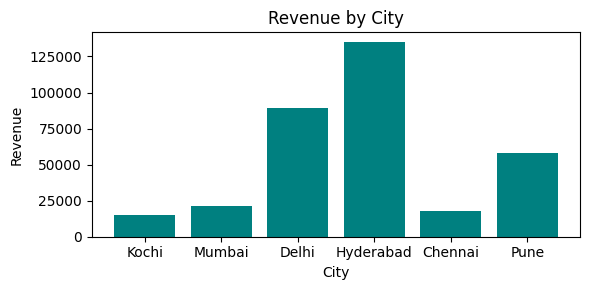

In [0]:
plt.figure(figsize=(6,3))
plt.bar(pdf_city['city'], pdf_city['revenue'], color='teal')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

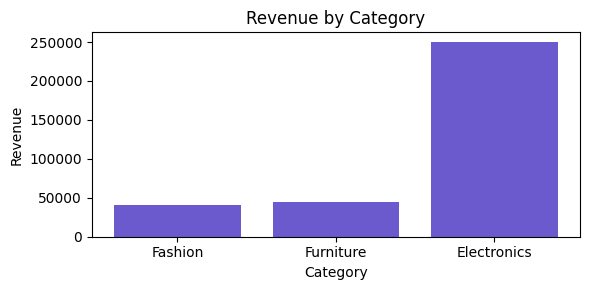

In [0]:
plt.figure(figsize=(6,3))
plt.bar(pdf_cat['category'], pdf_cat['revenue'], color='slateblue')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

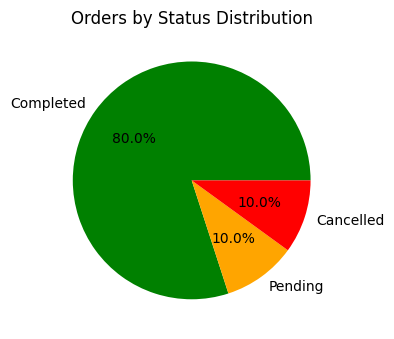

In [0]:
plt.figure(figsize=(4,4))
plt.pie(pdf_status['count'], labels=pdf_status['status'], autopct='%1.1f%%', colors=['green', 'orange', 'red'])
plt.title('Orders by Status Distribution')
plt.tight_layout()
plt.show()

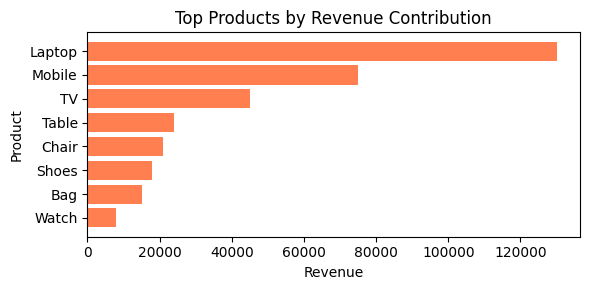

In [0]:
plt.figure(figsize=(6,3))
plt.barh(pdf_prod['product_name'], pdf_prod['revenue'], color='coral')
plt.gca().invert_yaxis()
plt.title('Top Products by Revenue Contribution')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

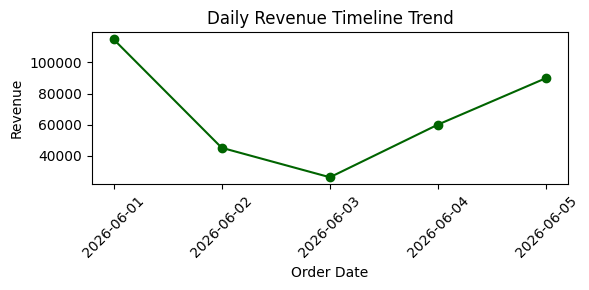

In [0]:
plt.figure(figsize=(6,3))
plt.plot(pdf_trend['order_date'], pdf_trend['revenue'], marker='o', color='darkgreen', linestyle='-')
plt.title('Daily Revenue Timeline Trend')
plt.xlabel('Order Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
df_silver_transformed.write.format("delta").mode("overwrite").saveAsTable("managed_retail_table")

In [0]:
df_silver_transformed.createOrReplaceTempView("temp_view_retail")

In [0]:
spark.sql("CREATE OR REPLACE VIEW global_shared_retail_view AS SELECT * FROM silver_retail_master")

print("Tables and Views built successfully under Serverless constraints.")

Tables and Views built successfully under Serverless constraints.
